In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import interp1d

In [2]:
MAX_SWITCHING_FREQUENCY = 10  # Hz
FRAME_TIME = 1.215  # s
n_frames = 100
osample = 256

tick_duration = 1/MAX_SWITCHING_FREQUENCY
tick = np.arange(n_frames*FRAME_TIME/tick_duration/3, dtype=int)

#switch 1 A=fiber1&2 B=fiber3
#duty cycle = fraction of time spent in high (output A) state
#This is correct for fiber3_on_fraction = 1/3 but wrong for some others, need to think about this more

fiber3_on_fraction = 1/3
fiber2_on_fraction = 1/3
fiber1_on_fraction = 1-fiber2_on_fraction-fiber3_on_fraction
assert fiber1_on_fraction>=0
n_states=2

switch1_duty_cycle = 1 - fiber3_on_fraction # 2/3 
switch2_duty_cycle = fiber1_on_fraction/(fiber2_on_fraction+fiber1_on_fraction)  # 1/2

# this is probably not the right formulation as we need the pattern tick period
switch1_on_at = tick * n_states/switch1_duty_cycle * tick_duration  # 0, 3, 6, ... * 1/freq
switch2_on_at = switch1_on_at
switch1_off_at = switch1_on_at + switch1_duty_cycle/fiber3_on_fraction * tick_duration  # 2, 5, 8, ... * 1/freq
switch2_off_at = switch2_on_at + switch2_duty_cycle*switch1_duty_cycle/fiber2_on_fraction * tick_duration  # 1, 4, 7, 10,  * 1/freq

# assuming switch1 and switch2 have rising edges aligned, which it will be as we switch synchronously
fiber_1_on_at = switch2_on_at[:-1]  
fiber_1_off_at = switch2_off_at[:-1]
fiber_2_on_at = switch2_off_at[:-1]
fiber_2_off_at = switch1_off_at[:-1]
fiber_3_on_at = switch1_off_at[:-1]
fiber_3_off_at = switch1_on_at[1:] #need to drop the first sample so it always comes on before off

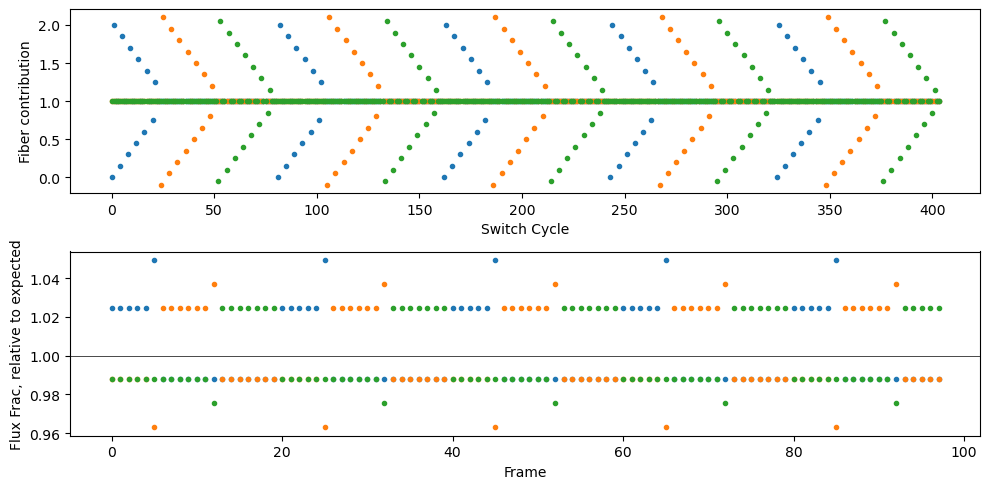

In [3]:
frame_starts = np.arange(n_frames+1)*FRAME_TIME+.1*tick_duration

frame_of_start = np.digitize(fiber_1_on_at, frame_starts, right=False)
is_split = frame_of_start != np.digitize(fiber_1_off_at,frame_starts)
shifted_fraction = np.fmod(fiber_1_off_at/FRAME_TIME,1)*FRAME_TIME*MAX_SWITCHING_FREQUENCY * is_split  #time illuminated in next frame
contrib = (1-shifted_fraction)
contrib[1:]+=shifted_fraction[:-1]
# contrib*=fiber1_on_fraction
flux_in_frame1 = np.histogram(frame_of_start,bins=np.arange(n_frames)+1, weights=contrib, density=False)[0]
plt.figure(figsize=(10,5))
plt.subplot(211)
plt.plot(contrib,'.')

frame_of_start = np.digitize(fiber_2_on_at, frame_starts, right=False)
is_split = frame_of_start != np.digitize(fiber_2_off_at,frame_starts)
shifted_fraction = np.fmod(fiber_2_off_at/FRAME_TIME,1)*FRAME_TIME*MAX_SWITCHING_FREQUENCY * is_split  #time illuminated in next frame
contrib = (1-shifted_fraction)
contrib[1:]+=shifted_fraction[:-1]
# contrib*=fiber2_on_fraction
flux_in_frame2 = np.histogram(frame_of_start,bins=np.arange(n_frames)+1, weights=contrib, density=False)[0]
plt.plot(contrib,'.')

frame_of_start = np.digitize(fiber_3_on_at, frame_starts, right=False)
is_split = frame_of_start != np.digitize(fiber_3_off_at,frame_starts)
shifted_fraction = np.fmod(fiber_3_off_at/FRAME_TIME,1)*FRAME_TIME*MAX_SWITCHING_FREQUENCY * is_split  #time illuminated in next frame
contrib = (1-shifted_fraction)
contrib[1:]+=shifted_fraction[:-1]
# contrib*=fiber3_on_fraction
flux_in_frame3 = np.histogram(frame_of_start,bins=np.arange(n_frames)+1, weights=contrib, density=False)[0]
plt.plot(contrib,'.')
plt.ylabel('Fiber contribution')
plt.xlabel('Switch Cycle')
# for x in frame_starts: plt.axvline(x, linewidth=.1, color='k')

plt.subplot(212)
total_flux_in_frame = flux_in_frame1+flux_in_frame2+flux_in_frame3
plt.plot(flux_in_frame1[:-1]/total_flux_in_frame[:-1]/fiber3_on_fraction,'.')
plt.plot(flux_in_frame2[:-1]/total_flux_in_frame[:-1]/fiber3_on_fraction,'.')
plt.plot(flux_in_frame3[:-1]/total_flux_in_frame[:-1]/fiber3_on_fraction,'.')
plt.axhline(1, linewidth=.5, color='k')
plt.ylabel('Flux Frac, relative to expected')
plt.xlabel('Frame')
plt.tight_layout()